<a href="https://colab.research.google.com/github/raksha1815/Raksha-pract/blob/main/Decision_Tree%20_Credit_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Dataset:
    Age  Income     Education  Employment  LoanAmount  CreditScore Property  \
0    22   20000      Graduate  Unemployed       50000          580       No   
1    25   25000      Graduate    Employed       60000          600       No   
2    28   30000      Graduate    Employed       80000          620       No   
3    30   35000  Postgraduate    Employed      100000          650      Yes   
4    32   40000  Postgraduate    Employed      120000          670      Yes   
5    35   45000  Postgraduate    Employed      150000          700      Yes   
6    38   50000      Graduate    Employed      140000          690      Yes   
7    40   55000  Postgraduate    Employed      180000          720      Yes   
8    42   60000  Postgraduate    Employed      200000          750      Yes   
9    45   65000  Postgraduate    Employed      220000          760      Yes   
10   48   70000      Graduate    Employed      250000          780      Yes   
11   50   75000  Postgraduate    Employed  

/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:407: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


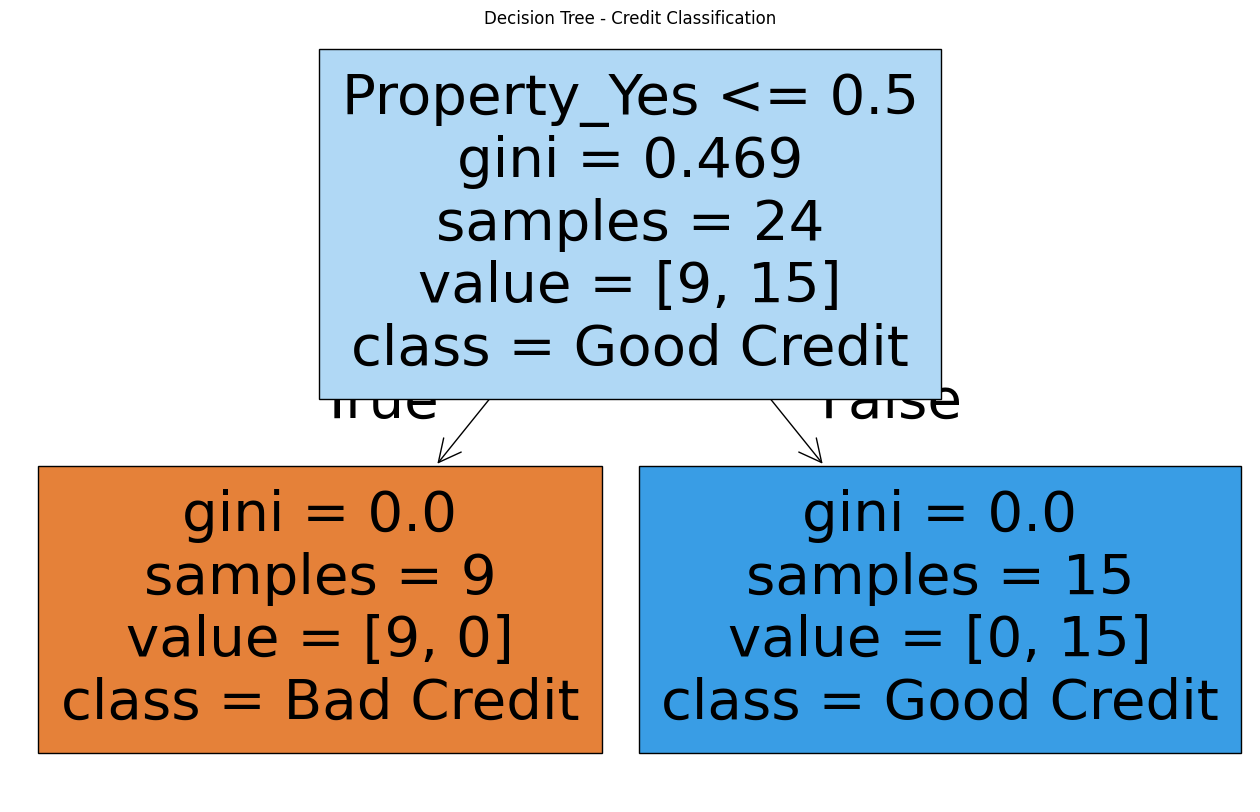

In [5]:
csv_data = """Age,Income,Education,Employment,LoanAmount,CreditScore,Property,Credit
22,20000,Graduate,Unemployed,50000,580,No,0
25,25000,Graduate,Employed,60000,600,No,0
28,30000,Graduate,Employed,80000,620,No,0
30,35000,Postgraduate,Employed,100000,650,Yes,1
32,40000,Postgraduate,Employed,120000,670,Yes,1
35,45000,Postgraduate,Employed,150000,700,Yes,1
38,50000,Graduate,Employed,140000,690,Yes,1
40,55000,Postgraduate,Employed,180000,720,Yes,1
42,60000,Postgraduate,Employed,200000,750,Yes,1
45,65000,Postgraduate,Employed,220000,760,Yes,1
48,70000,Graduate,Employed,250000,780,Yes,1
50,75000,Postgraduate,Employed,270000,800,Yes,1
23,22000,Graduate,Unemployed,50000,570,No,0
27,28000,Graduate,Employed,70000,610,No,0
29,32000,Graduate,Employed,90000,630,No,0
31,38000,Postgraduate,Employed,110000,660,Yes,1
34,42000,Graduate,Employed,130000,680,Yes,1
36,47000,Postgraduate,Employed,160000,710,Yes,1
39,52000,Graduate,Employed,150000,700,Yes,1
41,58000,Postgraduate,Employed,190000,730,Yes,1
44,62000,Postgraduate,Employed,210000,740,Yes,1
46,68000,Graduate,Employed,230000,770,Yes,1
49,72000,Postgraduate,Employed,260000,790,Yes,1
52,80000,Postgraduate,Employed,300000,810,Yes,1
24,24000,Graduate,Unemployed,55000,590,No,0
26,27000,Graduate,Employed,65000,605,No,0
33,39000,Graduate,Employed,100000,640,No,0
37,48000,Postgraduate,Employed,170000,715,Yes,1
43,61000,Graduate,Employed,200000,745,Yes,1
47,69000,Postgraduate,Employed,240000,775,Yes,1
"""

with open('credit_data.csv', 'w') as f:
    f.write(csv_data)

import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

# Read dataset
df = pd.read_csv("credit_data.csv")
print("Dataset:")
print(df)
# Convert categorical columns into numerical columns
df = pd.get_dummies(
    df,
    columns=['Education', 'Employment', 'Property'],
    drop_first=True
)
print("\nEncoded Dataset:")
print(df)
# Separate input and output
X = df.drop('Credit', axis=1)
y = df['Credit']
# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)
# Create Decision Tree
model = DecisionTreeClassifier(
    criterion='gini',
    random_state=42
)
# Train model
model.fit(X_train, y_train)
# Prediction
y_pred = model.predict(X_test)
# Accuracy
accuracy = accuracy_score(y_test, y_pred)
print("\nTest Accuracy:", accuracy)
# Confusion Matrix
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))
# Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))
# Display Decision Tree
plt.figure(figsize=(16, 10))
plot_tree(
    model,
    feature_names=X.columns,
    class_names=['Bad Credit', 'Good Credit'],
    filled=True
)
plt.title("Decision Tree - Credit Classification")
plt.show()